In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

from src.preprocessing.pca import PCA
from src.preprocessing.lda import LDA
from src.models.knn import KNN
from src.models.neural_network import NeuralNetwork
from src.data.splitter import stratified_train_test_split
from src.evaluation.metrics import accuracy, precision, recall, f1_score, confusion_matrix

In [2]:
data_path = Path("../data/processed/dry_bean_processed.npz")

data = np.load(data_path, allow_pickle=True)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

classes = data["classes"]
features = data["features"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("Classes:", classes)

X_train: (10836, 16)
X_test : (2707, 16)
y_train: (10836,)
y_test : (2707,)
Classes: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']


In [3]:
X_train_tune, X_val, y_train_tune, y_val = stratified_train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

print("Training   :", X_train_tune.shape)
print("Validation :", X_val.shape)

Training   : (8673, 16)
Validation : (2163, 16)


In [4]:
selection_metric = "F1"

In [5]:
k_values = [1, 3, 5, 7, 9, 11, 15]
weights_values = ["uniform", "distance"]

In [6]:
knn_results = []

for k in k_values:

    for weights in weights_values:

        knn = KNN(
            k=k,
            weights=weights
        )

        knn.fit(X_train_tune, y_train_tune)

        y_pred = knn.predict(X_val)

        knn_results.append({
            "model": "KNN",
            "k": k,
            "weights": weights,
            "Accuracy": accuracy(y_val, y_pred),
            "Precision": precision(y_val, y_pred),
            "Recall": recall(y_val, y_pred),
            "F1": f1_score(y_val, y_pred)
        })

In [7]:
knn_results_df = pd.DataFrame(knn_results)

knn_results_df = knn_results_df.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

knn_results_df

,model,k,weights,Accuracy,Precision,Recall,F1
0,KNN,3,distance,0.919556,0.934234,0.932252,0.933181
1,KNN,3,uniform,0.919094,0.934157,0.932210,0.933105
2,KNN,5,uniform,0.920018,0.932818,0.931165,0.931874
3,KNN,5,distance,0.919556,0.932408,0.930825,0.931507
4,KNN,15,distance,0.918632,0.931050,0.928633,0.929461
5,KNN,7,distance,0.917707,0.930899,0.928462,0.929393
6,KNN,15,uniform,0.918632,0.931081,0.928208,0.929226
7,KNN,7,uniform,0.916782,0.930188,0.928060,0.928816
8,KNN,11,distance,0.916782,0.929723,0.927389,0.928257
9,KNN,9,distance,0.915395,0.928512,0.926763,0.927354


In [8]:
best_knn = knn_results_df.iloc[0]

print("Best KNN:")
print(best_knn)

Best KNN:
model             KNN
k                   3
weights      distance
Accuracy     0.919556
Precision    0.934234
Recall       0.932252
F1           0.933181
Name: 0, dtype: object


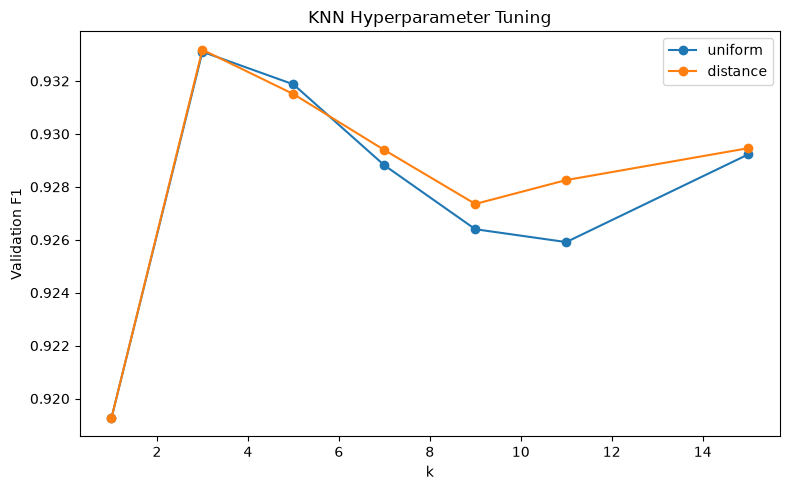

In [9]:
plt.figure(figsize=(8, 5))

for weights in weights_values:

    subset = knn_results_df[
        knn_results_df["weights"] == weights
    ]

    subset = subset.sort_values("k")

    plt.plot(
        subset["k"],
        subset["F1"],
        marker="o",
        label=weights
    )

plt.xlabel("k")
plt.ylabel("Validation F1")
plt.title("KNN Hyperparameter Tuning")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
learning_rates = [0.001, 0.01]
batch_sizes = [32, 64]
dropout_rates = [0.0, 0.2]
l2_values = [0.0, 1e-4]
layer_sizes = [16, 32, 16, 7]
activations = ["relu", "sigmoid"]

In [21]:
nn_results = []

for activation in activations:

    for learning_rate in learning_rates:

        for batch_size in batch_sizes:

            for dropout_rate in dropout_rates:

                nn = NeuralNetwork(
                    layer_sizes=[16, 32, 16, 7],
                    activation=activation,
                    learning_rate=learning_rate,
                    epochs=100,
                    batch_size=batch_size,
                    dropout_rate=dropout_rate,
                    random_state=42
                )

                nn.fit(
                    X_train_tune,
                    y_train_tune,
                    X_val,
                    y_val
                )

                y_pred = nn.predict(X_val)

                nn_results.append({
                    "model": "Neural Network",
                    "activation": activation,
                    "learning_rate": learning_rate,
                    "batch_size": batch_size,
                    "dropout_rate": dropout_rate,
                    "Accuracy": accuracy(y_val, y_pred),
                    "Precision": precision(y_val, y_pred),
                    "Recall": recall(y_val, y_pred),
                    "F1": f1_score(y_val, y_pred)
                })

In [22]:
nn_results_df = pd.DataFrame(nn_results)

nn_results_df = nn_results_df.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

nn_results_df

,model,activation,learning_rate,batch_size,dropout_rate,Accuracy,Precision,Recall,F1
0,Neural Network,relu,0.010,64,0.2,0.924179,0.936172,0.933921,0.934866
1,Neural Network,relu,0.010,64,0.0,0.924179,0.934120,0.933595,0.933743
2,Neural Network,relu,0.010,32,0.2,0.922792,0.934474,0.931793,0.932882
3,Neural Network,relu,0.010,32,0.0,0.920018,0.931500,0.929760,0.930299
4,Neural Network,relu,0.001,32,0.0,0.914933,0.926988,0.924770,0.925608
5,Neural Network,relu,0.001,64,0.0,0.912159,0.924942,0.920434,0.922390
6,Neural Network,relu,0.001,32,0.2,0.909847,0.922597,0.919118,0.920484
7,Neural Network,sigmoid,0.010,32,0.0,0.903375,0.916619,0.912471,0.914363
8,Neural Network,relu,0.001,64,0.2,0.899676,0.916494,0.908939,0.911103
9,Neural Network,sigmoid,0.010,32,0.2,0.873786,0.883562,0.824384,0.837855


In [23]:
activation_summary = (
    nn_results_df
    .groupby("activation")[["Accuracy", "Precision", "Recall", "F1"]]
    .mean()
)

activation_summary

,Accuracy,Precision,Recall,F1
activation,,,,
relu,0.915973,0.928411,0.925291,0.926422
sigmoid,0.655802,0.544622,0.566804,0.532843


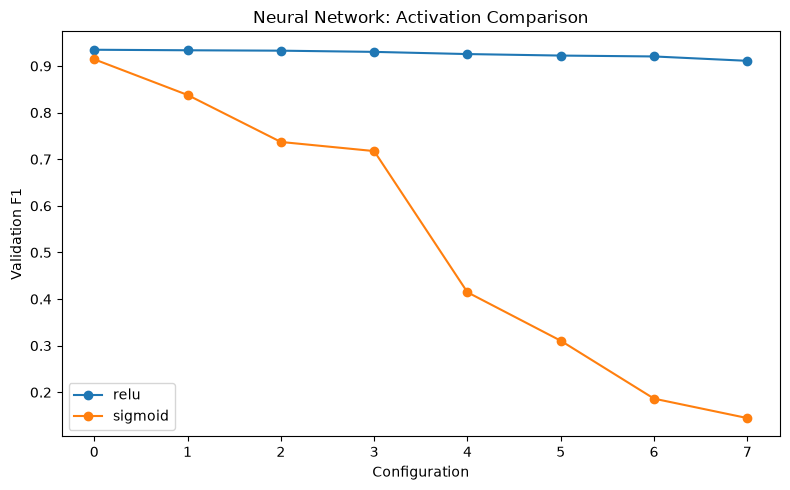

In [24]:
plt.figure(figsize=(8, 5))

for activation in activations:

    subset = nn_results_df[
        nn_results_df["activation"] == activation
    ]

    plt.plot(
        subset["F1"].values,
        marker="o",
        label=activation
    )

plt.xlabel("Configuration")
plt.ylabel("Validation F1")
plt.title("Neural Network: Activation Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
knn_results_df.to_csv(
    "../experiments/comparison/knn_hyperparameter_results.csv",
    index=False
)

In [27]:
nn_results_df.to_csv(
    "../experiments/comparison/nn_hyperparameter_results.csv",
    index=False
)